In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import loadmat
import pickle
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit
from scipy.integrate import quad
def one_state_model(x,c, m1, sigma1):
    return c/np.sqrt(2*np.pi*sigma1**2)*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))

def one_state_model_fixed(x,c):
    m1 = 0
    sigma1 = 46
    return c/np.sqrt(2*np.pi*sigma1**2)*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))


def two_state_model(x,c1, c2, m1, sigma1, m2, sigma2):
    # no constraints
    return ((c1/np.sqrt(2*np.pi*sigma1**2))*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+
                                               np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))+
    (c2/np.sqrt(2*np.pi*sigma2**2))*(np.exp(-(-x-m2)**2/(2*sigma2**2))+np.exp(-(2*180-x-m2)**2/(2*sigma2**2))+
                                      np.exp(-(x-m2)**2/(2*sigma2**2))+np.exp(-(-2*180+x-m2)**2/(2*sigma2**2))))

def two_state_model_groundFixed_wCons(x, c2, m2, sigma2):
    m1 = 0
    sigma1 = 46
    # c1>c2, delc = c1-c2
    return (((1-c2)/np.sqrt(2*np.pi*sigma1**2))*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+
                                               np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))+
    (c2/np.sqrt(2*np.pi*sigma2**2))*(np.exp(-(-x-m2)**2/(2*sigma2**2))+np.exp(-(2*180-x-m2)**2/(2*sigma2**2))+
                                      np.exp(-(x-m2)**2/(2*sigma2**2))+np.exp(-(-2*180+x-m2)**2/(2*sigma2**2))))

def num_good_frames(x):
    return sum(~np.isnan(x))


from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905], 
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143], 
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286], 
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238, 
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571], 
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429], 
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667, 
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286], 
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429], 
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524, 
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048, 
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667], 
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381], 
 [0.0589714286, 0.6837571429, 0.7253857143], 
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429], 
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048], 
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619, 
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667], 
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905], 
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476, 
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143], 
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333], 
 [0.7184095238, 0.7411333333, 0.3904761905], 
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667, 
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762], 
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217], 
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619], 
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857, 
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381], 
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857], 
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309], 
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333], 
 [0.9763, 0.9831, 0.0538]]

# Create the colormap
parula_map = LinearSegmentedColormap.from_list('parula', cm_data)
parula_map.set_bad(parula_map(0))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.usetex'] = 0

def plot_bootstrap_fit(data_angles, n_bootstraps=500, seed=0):
    np.random.seed(seed)
    edges = np.arange(0, 185, 5)
    bin_centers = edges[:-1] + 2.5
    size_bootstrap = len(data_angles)

    def bent_state_model(x, m1, sigma1):
        return 1/np.sqrt(2*np.pi*sigma1**2) * (
            np.exp(-(-x-m1)**2/(2*sigma1**2)) +
            np.exp(-(2*180-x-m1)**2/(2*sigma1**2)) +
            np.exp(-(x-m1)**2/(2*sigma1**2)) +
            np.exp(-(-2*180+x-m1)**2/(2*sigma1**2))
        )

    initial_guess = [0, 40]
    bounds = ((0, 10), (180, 100))
    boot_mu, boot_sigma = [], []

    for i in range(n_bootstraps):
        resampled = np.random.choice(data_angles, size=size_bootstrap, replace=True)
        binned, _ = np.histogram(resampled, edges, density=True)
        sigma = np.sqrt(binned / 5 / sum(~np.isnan(resampled)))
        sigma[sigma == 0] = 1
        try:
            popt_r, _ = curve_fit(bent_state_model, bin_centers, binned,
                                  p0=initial_guess, bounds=bounds,
                                  sigma=sigma, absolute_sigma=False, maxfev=int(1e6),
                                  ftol=1e-15, xtol=1e-15, gtol=1e-15)
            boot_mu.append(popt_r[0])
            boot_sigma.append(popt_r[1])
        except RuntimeError:
            continue

    mean_error = np.std(boot_mu)
    stddev_error = np.std(boot_sigma)

    # Fit on full data
    binned_data, _ = np.histogram(data_angles, edges, density=True)
    sigma = np.sqrt(binned_data / 5 / sum(~np.isnan(data_angles)))
    sigma[sigma == 0] = 1
    popt, pcov = curve_fit(bent_state_model, bin_centers, binned_data,
                           p0=initial_guess, bounds=bounds,
                           sigma=sigma, method='trf', absolute_sigma=False, maxfev=int(1e6),
                           ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Plot
    fig, ax = plt.subplots()
    sns.histplot(data_angles, bins=np.arange(0, 185, 5), stat='density',
                 common_norm=False, color='#E69F00', ax=ax)
    ax.plot(bin_centers, bent_state_model(bin_centers, *popt),
            label='One folded normal', color='Blue', linewidth=3, linestyle='--')
    ax.text(0.7, 0.55,
            f'$\\mu_1={popt[0]:.1f}\\pm{mean_error:.1f}$\n$\\sigma_1={popt[1]:.1f}\\pm{stddev_error:.1f}$',
            transform=ax.transAxes, verticalalignment='top',
            horizontalalignment='center', fontsize=15)
    ax.set_xlim(0, 180)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
    ax.set_xlabel('Bend Angle (degrees)', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(percentage_formatter))
    ax.text(-0.05, 1.02, '%', transform=ax.transAxes, fontsize=14,
            va='bottom', ha='center')
    ax.set_aspect('auto')
    plt.tight_layout()

    return popt, mean_error, stddev_error

def plot_bootstrap_2tf_fit(data_angles, n_bootstraps=500, seed=0,
                           m1=0, sigma1=46,
                           initial_guess=[0.2, 60, 30],
                           bounds=((0, 0, 10), (0.5, 180, 100)),
                           r2_tolerance=0.05,
                           c2_min=0.03, c2_max=0.5):
    rng = np.random.default_rng(seed=seed)
    edges = np.arange(0, 185, 5)
    bin_centers = edges[:-1] + 2.5
    size_bootstrap = len(data_angles)
    lb, ub = bounds   # lower and upper bound tuples

    def two_state_model_groundFixed_wCons(x, c2, m2, sigma2):
        return (((1-c2)/np.sqrt(2*np.pi*sigma1**2)) *
                (np.exp(-(-x-m1)**2/(2*sigma1**2)) + np.exp(-(2*180-x-m1)**2/(2*sigma1**2)) +
                 np.exp(-(x-m1)**2/(2*sigma1**2)) + np.exp(-(-2*180+x-m1)**2/(2*sigma1**2))) +
                (c2/np.sqrt(2*np.pi*sigma2**2)) *
                (np.exp(-(-x-m2)**2/(2*sigma2**2)) + np.exp(-(2*180-x-m2)**2/(2*sigma2**2)) +
                 np.exp(-(x-m2)**2/(2*sigma2**2)) + np.exp(-(-2*180+x-m2)**2/(2*sigma2**2))))

    def one_state_model(x, c, m, sigma):
        return (c/np.sqrt(2*np.pi*sigma**2)) * (
            np.exp(-(-x-m)**2/(2*sigma**2)) + np.exp(-(2*180-x-m)**2/(2*sigma**2)) +
            np.exp(-(x-m)**2/(2*sigma**2)) + np.exp(-(-2*180+x-m)**2/(2*sigma**2)))

    def r_squared(y_obs, y_pred):
        ss_res = np.sum((y_obs - y_pred) ** 2)
        ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
        return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # ── Fit on full data first (to get reference R²) ─────────────────
    binned_data, _ = np.histogram(data_angles, edges, density=True)
    sigma = np.sqrt(binned_data / 5 / sum(~np.isnan(data_angles)))
    sigma[sigma == 0] = 1
    popt, pcov = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned_data,
                           p0=initial_guess, bounds=bounds,
                           sigma=sigma, absolute_sigma=False, maxfev=int(1e6),
                           ftol=1e-15, xtol=1e-15, gtol=1e-15)
    r2_orig = r_squared(binned_data,
                        two_state_model_groundFixed_wCons(bin_centers, *popt))

    # ── Bootstrap with random initial conditions + filters ───────────
    boot_mu2, boot_sigma2, boot_c2, boot_r2 = [], [], [], []
    n_runtime = n_rej_r2 = n_rej_c2 = 0

    for i in range(n_bootstraps):
        resampled = rng.choice(data_angles, size=size_bootstrap, replace=True)
        binned, _ = np.histogram(resampled, edges, density=True)
        sigma_sub = np.sqrt(binned / 5 / sum(~np.isnan(resampled)))
        sigma_sub[sigma_sub == 0] = 1

        # Random initial conditions, uniform within bounds for c2, m2, sigma2
        random_init = [rng.uniform(lb[j], ub[j]) for j in range(3)]

        try:
            popt_r, _ = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned,
                                  p0=random_init, bounds=bounds,
                                  sigma=sigma_sub, absolute_sigma=False, maxfev=int(1e6),
                                  ftol=1e-15, xtol=1e-15, gtol=1e-15)
        except RuntimeError:
            n_runtime += 1
            continue

        c2_val, mu2_val, sg2_val = popt_r
        r2_val = r_squared(binned,
                           two_state_model_groundFixed_wCons(bin_centers, *popt_r))

        # Filter: R² must be within tolerance of original
        if r2_val < r2_orig - r2_tolerance:
            n_rej_r2 += 1
            continue
        # Filter: c2 must be in (c2_min, c2_max) strictly
        if not (c2_min < c2_val < c2_max):
            n_rej_c2 += 1
            continue

        boot_c2.append(c2_val)
        boot_mu2.append(mu2_val)
        boot_sigma2.append(sg2_val)
        boot_r2.append(r2_val)

    n_accepted = len(boot_c2)
    print(f"Bootstrap: {n_accepted}/{n_bootstraps} accepted "
          f"(runtime errors: {n_runtime}, R² rejects: {n_rej_r2}, "
          f"c2 rejects: {n_rej_c2})")
    print(f"  Original R² = {r2_orig:.4f}, threshold = {r2_orig - r2_tolerance:.4f}")

    mean_error   = np.std(boot_mu2)   if boot_mu2   else np.nan
    stddev_error = np.std(boot_sigma2) if boot_sigma2 else np.nan
    c2_error     = np.std(boot_c2)    if boot_c2    else np.nan

    # ── Plot ─────────────────────────────────────────────
    fig, ax = plt.subplots()
    sns.histplot(data_angles, bins=np.arange(0, 185, 5), stat='density',
                 common_norm=False, color='white', ax=ax)
    ax.plot(bin_centers, two_state_model_groundFixed_wCons(bin_centers, *popt),
            label='Two folded normal', color='purple', linewidth=3)
    ax.plot(bin_centers, one_state_model(bin_centers, 1-popt[0], m1, sigma1),
            label='Ground state', color='blue', linewidth=3, linestyle='--')
    ax.plot(bin_centers, one_state_model(bin_centers, *popt),
            label='Bent state', color='red', linewidth=3, linestyle='-.')
    ax.text(0.7, 0.65,
            f'$\\mu_2={popt[1]:.0f}\\pm{mean_error:.0f}$\n'
            f'$\\sigma_2={popt[2]:.0f}\\pm{stddev_error:.0f}$\n'
            f' $C_2 ={popt[0]:.2f}\\pm{c2_error:.02f}$',
            transform=ax.transAxes, verticalalignment='top',
            horizontalalignment='center', fontsize=15)
    ax.set_xlim(0, 180)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
    ax.set_xlabel('Bend Angles (degrees)', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x*100:.1f}'))
    ax.text(-0.05, 1.02, '%', transform=ax.transAxes, fontsize=14,
            va='bottom', ha='center')
    ax.set_aspect('auto')
    plt.tight_layout()

    return popt, mean_error, stddev_error, c2_error

In [2]:
amber_data_3 = loadmat('../c230513_03_all_nunchuck_data.mat')
linkers_data_3_raw = amber_data_3['data'][0][0][1]
linkers_data_3 = pd.Series([item[0] for item in linkers_data_3_raw[0]])
nnba_data_3_raw = amber_data_3['data'][0][0][2]
nnba_data_3 = pd.Series([abs(item[0]) for item in nnba_data_3_raw[0]])
names_data_3_raw = amber_data_3['data'][0][0][0]
names_data_3 = pd.Series([item[0] for item in names_data_3_raw[0]])
nnba_data_3.index = names_data_3

data_to_select_37alt = ['37PP_nsIHF_MBN','37PP_nsIHF_new','37PP_nsIHF_2023'] 
data_to_select_37ori = ['37PP0At','37PP0At_LS','37PP0At_newSEs','37PP0At_noT_new','37PP0n0At',
                  '37PP1n0At','37PP0At_cont_study','37PP0At_long_movies','37PP0At_fresh','37PP0At_1week','37PP0At_1week_0.2ul_MBN'];

matching_indices_37alt = np.where(np.isin(linkers_data_3, data_to_select_37alt))[0] 
heatmap_movies_37alt = nnba_data_3.iloc[matching_indices_37alt].reset_index(drop=True)
name_heatmap_movies_37alt = names_data_3.iloc[matching_indices_37alt].reset_index(drop=True)
heatmap_movies_37alt.index = name_heatmap_movies_37alt

matching_indices_37ori = np.where(np.isin(linkers_data_3, data_to_select_37ori))[0]
heatmap_movies_37ori = nnba_data_3.iloc[matching_indices_37ori].reset_index(drop=True)
name_heatmap_movies_37ori = names_data_3.iloc[matching_indices_37ori].reset_index(drop=True)
heatmap_movies_37ori.index = name_heatmap_movies_37ori
heatmap_movies_37ori=heatmap_movies_37ori[amber_data_3['data']['delay'][0][0][0][matching_indices_37ori] <0.2]

edges = np.arange(0, 185, 5)
bin_centers = edges[:-1] + 2.5

During the process of data uploading, we found 37PP_nsIHF_MBN were actually taken at 2hz instead of 10hz. So we decided to discard those bootstrapped results. We noticed, there's no significant difference in the final result.

In [4]:
heatmap_37PPnsIHF = heatmap_movies_37alt.apply(lambda x: x[:3000])
lengths = heatmap_37PPnsIHF.apply(num_good_frames)
print(f"Min frames: {lengths.min()}")
print(f"Max frames: {lengths.max()}")
print(f"Sequences at the 3000-frame cap: {(lengths == 3000).sum()}")
print(f"Sequences shorter than 3000:     {(lengths < 3000).sum()}")

# this is for replicating amber's results 仔细看！
boot_mu2_all_wCons = []
boot_name_all_wCons = []
boot_sigma2_all_wCons = []
boot_c2_all_wCons = []
processed_series = heatmap_37PPnsIHF #####
edges = np.arange(0, 185, 5)
bin_centers = edges[:-1] + 2.5
rng = np.random.default_rng(seed=0)
def two_state_model_groundFixed_wCons(x, c2, m2, sigma2):
    m1 = 0
    sigma1 = 46
    # c1>c2,
    return (((1-c2)/np.sqrt(2*np.pi*sigma1**2))*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+
                                               np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))+
    (c2/np.sqrt(2*np.pi*sigma2**2))*(np.exp(-(-x-m2)**2/(2*sigma2**2))+np.exp(-(2*180-x-m2)**2/(2*sigma2**2))+
                                      np.exp(-(x-m2)**2/(2*sigma2**2))+np.exp(-(-2*180+x-m2)**2/(2*sigma2**2))))

for j in range(len(processed_series)):
    n_bootstraps = 1000
    size_bootstrap = len(processed_series.iloc[j])
    boot_mu2 = []
    boot_name = []
    boot_sigma2 = []
    boot_c2 = []
    binned_original, _ = np.histogram(processed_series.iloc[j], np.arange(0,185,5), density=True)
    initial_guess = [0.2, 60,  30]
    bounds = ((0,0, 10), (0.5, 180, 100))
    sigma_subset = np.sqrt(binned_original/5/sum(~np.isnan(processed_series.iloc[j])))
    sigma_subset[sigma_subset==0]=1
    popt_ref, _ = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned_original, p0=initial_guess, bounds=bounds,
                            sigma=sigma_subset, absolute_sigma=False, maxfev=100000,
                            method='trf', ftol=1e-15, xtol=1e-15, gtol=1e-15)
    r2_cutoff = r2_score(binned_original,two_state_model_groundFixed_wCons(bin_centers,*popt_ref))
    for i in range(n_bootstraps):
        # Resample the histogram values (binned processed_series) using the histogram distribution
        
        try:
            random_mu = rng.uniform(0, 180)
            random_sigma = rng.uniform(10, 100)
            initial_guess = [0.2, random_mu,  random_sigma]
            resampled_hist = rng.choice(processed_series.iloc[j], size=(1,size_bootstrap), replace=True)[0]
            binned_data, _ = np.histogram(resampled_hist, np.arange(0,185,5), density=True)
            sigma_subset = np.sqrt(binned_data/5/sum(~np.isnan(resampled_hist)))
            sigma_subset[sigma_subset==0]=1
            popt_resample, _ = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned_data, p0=initial_guess, bounds=bounds,
                                        sigma=sigma_subset, absolute_sigma=False, maxfev=100000,
                                        method='trf', ftol=1e-15, xtol=1e-15, gtol=1e-15)
            r2 = r2_score(binned_data, two_state_model_groundFixed_wCons(bin_centers,*popt_resample))
            if (r2 > r2_cutoff - 0.05): 
                boot_mu2.append(popt_resample[1])
                boot_sigma2.append(popt_resample[2])
                boot_name.append(processed_series.index[j])
                boot_c2.append(popt_resample[0])
        except RuntimeError:
            # Handle occasional fitting failures
            continue
    boot_mu2_all_wCons.append(np.array(boot_mu2))
    boot_sigma2_all_wCons.append(np.array(boot_sigma2))
    boot_name_all_wCons.append(boot_name)

    boot_c2_all_wCons.append(np.array(boot_c2))

df = pd.DataFrame({'mu': np.concatenate(boot_mu2_all_wCons), 'sigma': np.concatenate(boot_sigma2_all_wCons), 
                   'c2': np.concatenate(boot_c2_all_wCons),
                   'index': np.concatenate(boot_name_all_wCons)})
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'wb') as f:
    pickle.dump(df, f)

In [8]:
heatmap_37PP0At = heatmap_movies_37ori.apply(lambda x: x[:3000])
heatmap_37PPnsIHF = heatmap_movies_37alt.apply(lambda x: x[:3000])

In [802]:
heatmap_37PP0At = heatmap_movies_37ori.apply(lambda x: x[:3000])
lengths = heatmap_37PP0At.apply(num_good_frames)
print(f"Min frames: {lengths.min()}")
print(f"Max frames: {lengths.max()}")
print(f"Sequences at the 3000-frame cap: {(lengths == 3000).sum()}")
print(f"Sequences shorter than 3000:     {(lengths < 3000).sum()}")

# this is for replicating amber's results 仔细看！
boot_mu2_all_wCons = []
boot_name_all_wCons = []
boot_sigma2_all_wCons = []
boot_c2_all_wCons = []
processed_series = heatmap_37PP0At #####
edges = np.arange(0, 185, 5)
bin_centers = edges[:-1] + 2.5
rng = np.random.default_rng(seed=0)
def two_state_model_groundFixed_wCons(x, c2, m2, sigma2):
    m1 = 0
    sigma1 = 46
    # c1>c2,
    return (((1-c2)/np.sqrt(2*np.pi*sigma1**2))*(np.exp(-(-x-m1)**2/(2*sigma1**2))+np.exp(-(2*180-x-m1)**2/(2*sigma1**2))+
                                               np.exp(-(x-m1)**2/(2*sigma1**2))+np.exp(-(-2*180+x-m1)**2/(2*sigma1**2)))+
    (c2/np.sqrt(2*np.pi*sigma2**2))*(np.exp(-(-x-m2)**2/(2*sigma2**2))+np.exp(-(2*180-x-m2)**2/(2*sigma2**2))+
                                      np.exp(-(x-m2)**2/(2*sigma2**2))+np.exp(-(-2*180+x-m2)**2/(2*sigma2**2))))

for j in range(len(processed_series)):
    n_bootstraps = 1000
    size_bootstrap = len(processed_series.iloc[j])
    boot_mu2 = []
    boot_name = []
    boot_sigma2 = []
    boot_c2 = []
    binned_original, _ = np.histogram(processed_series.iloc[j], np.arange(0,185,5), density=True)
    initial_guess = [0.2, 60,  30]
    bounds = ((0,0, 10), (0.5, 180, 100))
    sigma_subset = np.sqrt(binned_original/5/sum(~np.isnan(processed_series.iloc[j])))
    sigma_subset[sigma_subset==0]=1
    popt_ref, _ = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned_original, p0=initial_guess, bounds=bounds,
                            sigma=sigma_subset, absolute_sigma=False, maxfev=100000,
                            method='trf', ftol=1e-15, xtol=1e-15, gtol=1e-15)
    # popt_ref, _ = curve_fit(one_state_model, bin_centers, binned_data, p0=[1,0,40], bounds=((0,0,10),(+np.inf,180,180)),
    #                        sigma=sigma_subset, absolute_sigma=False, maxfev=1e6)
    r2_cutoff = r2_score(binned_original,two_state_model_groundFixed_wCons(bin_centers,*popt_ref))
    for i in range(n_bootstraps):
        # Resample the histogram values (binned processed_series) using the histogram distribution
        
        try:
            random_mu = rng.uniform(0, 180)
            random_sigma = rng.uniform(10, 100)
            initial_guess = [0.2, random_mu,  random_sigma]
            resampled_hist = rng.choice(processed_series.iloc[j], size=(1,size_bootstrap), replace=True)[0]
            binned_data, _ = np.histogram(resampled_hist, np.arange(0,185,5), density=True)
            sigma_subset = np.sqrt(binned_data/5/sum(~np.isnan(resampled_hist)))
            sigma_subset[sigma_subset==0]=1
            popt_resample, _ = curve_fit(two_state_model_groundFixed_wCons, bin_centers, binned_data, p0=initial_guess, bounds=bounds,
                                        sigma=sigma_subset, absolute_sigma=False, maxfev=100000,
                                        method='trf', ftol=1e-15, xtol=1e-15, gtol=1e-15)
            r2 = r2_score(binned_data, two_state_model_groundFixed_wCons(bin_centers,*popt_resample))
            if (r2 > r2_cutoff - 0.05): 
                boot_mu2.append(popt_resample[1])
                boot_sigma2.append(popt_resample[2])
                boot_name.append(processed_series.index[j])
                boot_c2.append(popt_resample[0])
        except RuntimeError:
            # Handle occasional fitting failures
            continue
    boot_mu2_all_wCons.append(np.array(boot_mu2))
    boot_sigma2_all_wCons.append(np.array(boot_sigma2))
    boot_name_all_wCons.append(boot_name)

    boot_c2_all_wCons.append(np.array(boot_c2))

df = pd.DataFrame({'mu': np.concatenate(boot_mu2_all_wCons), 'sigma': np.concatenate(boot_sigma2_all_wCons), 
                   'c2': np.concatenate(boot_c2_all_wCons),
                   'index': np.concatenate(boot_name_all_wCons)})
with open('260605_37PP0Atshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'wb') as f:
    pickle.dump(df, f)

Min frames: 765
Max frames: 2999
Sequences at the 3000-frame cap: 0
Sequences shorter than 3000:     91


In [5]:
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df = pickle.load(f)
print(len(df))
# df = df[~df['index'].isin(['230330_5pm_9_37PPnsIHF', '230331_4pm_4_37PPnsIHF'])]
df = df[(df['mu'] >= 0) & (df['mu'] <= 140) &
        (df['sigma'] >= 11) & (df['sigma'] <= 60)]

print(len(df))
print(df['index'].nunique())
df = df[((1 - df['c2']) > 1.0001 * df['c2'])]
df.reset_index(inplace=True, drop=True)
print(len(df))
len(df['index'].unique())

75359
66337
77
28362


74

In [1499]:
with open('260605_37PP0Atshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df = pickle.load(f)
print(len(df))
# df = df[~df['index'].isin(['230330_5pm_9_37PPnsIHF', '230331_4pm_4_37PPnsIHF'])]
df = df[(df['mu'] >= 0) & (df['mu'] <= 140) &
        (df['sigma'] >= 11) & (df['sigma'] <= 60)]
print(len(df['index'].unique()))
print(len(df))
df = df[((1 - df['c2']) > 1.0001 * df['c2'])]
df.reset_index(inplace=True, drop=True)
print(len(df))
len(df['index'].unique())

81907
91
71267
26249


81

4 excluded molecules: ['movie220326_12pm_03nca_37PP_nsIHF', 'movie220326_12pm_03ncb_37PP_nsIHF', '230331_4pm_14_37PPnsIHF', '230331_4pm_8_37PPnsIHF']


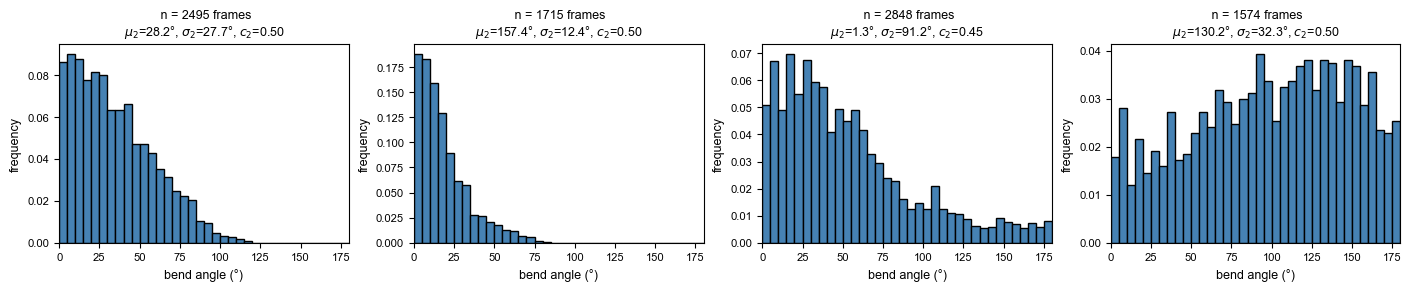

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def filter_df(df):
    df = df[(1 - df['c2']) > 1.0001 * df['c2']]
    df = df[(df['mu']    >= 0)  & (df['mu']    <= 140) &
            (df['sigma'] >= 11) & (df['sigma'] <= 60)]
    return df.reset_index(drop=True)
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df_raw = pickle.load(f)
# ── Get indices of excluded molecules ────────────────────────────────
all_mols  = df_raw['index'].unique()
df_filt   = filter_df(df_raw)
kept_mols = set(df_filt['index'].unique())
excluded  = [m for m in all_mols if m not in kept_mols]
print(f"{len(excluded)} excluded molecules: {excluded}")

# ── Plot bend-angle histograms from heatmap_37PP0At ──────────────────
edges = np.arange(0, 185, 5)
bin_centers = edges[:-1] + 2.5

ncols = 4
nrows = (len(excluded) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(3.5 * ncols, 2.8 * nrows),
                         constrained_layout=True, squeeze=False)

for idx, mol in enumerate(excluded):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]

    # Bend angles for this molecule
    angles = np.abs(heatmap_37PPnsIHF.loc[mol]) ###############
    angles = angles[~np.isnan(angles)]
    weights = np.ones_like(angles) / len(angles)
    ax.hist(angles, bins=edges, color='steelblue', edgecolor='black',
            weights=weights)
    # Bootstrap-median fit parameters
    sub    = df_raw[df_raw['index'] == mol]
    c2_med = np.median(sub['c2'])
    mu_med = np.median(sub['mu'])
    sg_med = np.median(sub['sigma'])

    # ax.hist(angles, bins=edges, color='steelblue', edgecolor='black',
    #         density=True)
    ax.set_xlim(0, 180)
    ax.set_title(
        f' n = {len(angles)} frames\n'
        f'$\\mu_2$={mu_med:.1f}°, $\\sigma_2$={sg_med:.1f}°, '
        f'$c_2$={c2_med:.2f}',
        fontsize=9)
    ax.set_xlabel('bend angle (°)', fontsize=9)
    ax.set_ylabel('frequency', fontsize=9)
    ax.tick_params(labelsize=8)

for idx in range(len(excluded), nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].set_visible(False)

plt.savefig('260615_alternate_excluded_molecules_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

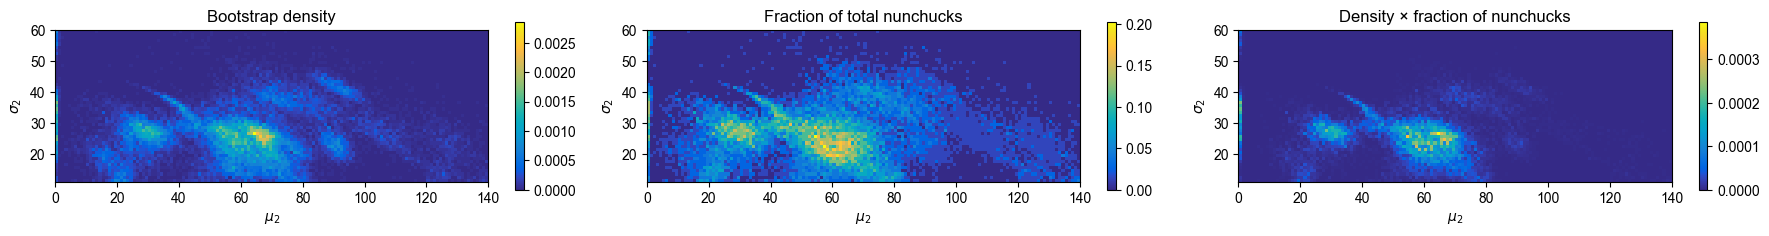

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df = pickle.load(f)

df = df[(df['mu'] >= 0) & (df['mu'] <= 140) &
        (df['sigma'] >= 11) & (df['sigma'] <= 60)]
df = df[((1 - df['c2']) > 1.0001 * df['c2'])]
df.reset_index(inplace=True, drop=True)
n_total_mols = df['index'].nunique()

x_bins = np.arange(0, 141, 1)
y_bins = np.arange(11, 61, 1)

# ── 1) Bootstrap density ────────────────────────────────────────────
hist, _, _ = np.histogram2d(
    df['mu'], df['sigma'],
    bins=(x_bins, y_bins), density=True,
)

# ── 2) Unique-molecule count per bin ────────────────────────────────
mu_idx = np.clip(np.digitize(df['mu'],    x_bins) - 1, 0, len(x_bins) - 2)
sg_idx = np.clip(np.digitize(df['sigma'], y_bins) - 1, 0, len(y_bins) - 2)

pairs = pd.DataFrame({
    'mu_bin': mu_idx, 'sg_bin': sg_idx, 'mol': df['index'].values,
}).drop_duplicates()
counts = pairs.groupby(['mu_bin', 'sg_bin']).size()



mol_count = np.zeros_like(hist, dtype=int)
mol_count[counts.index.get_level_values(0),
          counts.index.get_level_values(1)] = counts.values

# ── 3) Combined: density × #molecules ───────────────────────────────
combined = hist * mol_count / n_total_mols

# ── 4) Plot ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, arr, title, cbar_label in zip(
    axes,
    [hist, mol_count.astype(float)/n_total_mols, combined],
    ['Bootstrap density', 'Fraction of total nunchucks', 'Density × fraction of nunchucks'],
    ['ρ', 'N_mol', 'ρ · N_mol'],
):
    m = ax.pcolormesh(x_bins, y_bins, arr.T, cmap=parula_map, shading='flat')
    plt.colorbar(m, ax=ax, shrink=0.4)
    ax.set_title(title); ax.set_xlabel(r'$\mu_2$'); ax.set_ylabel(r'$\sigma_2$')
    ax.set_xlim(0, 140); ax.set_ylim(11, 60); ax.set_aspect('equal')
plt.tight_layout()
# plt.savefig('260607_prewatershed_ori.png',dpi=300)

37PP0At: 26249 pts, 81 mols → 29 mols ≥10% in cluster 1 → 13669 pts retained
37PPnsIHF: 21423 pts, 54 mols → 20 mols ≥10% in cluster 1 → 12090 pts retained


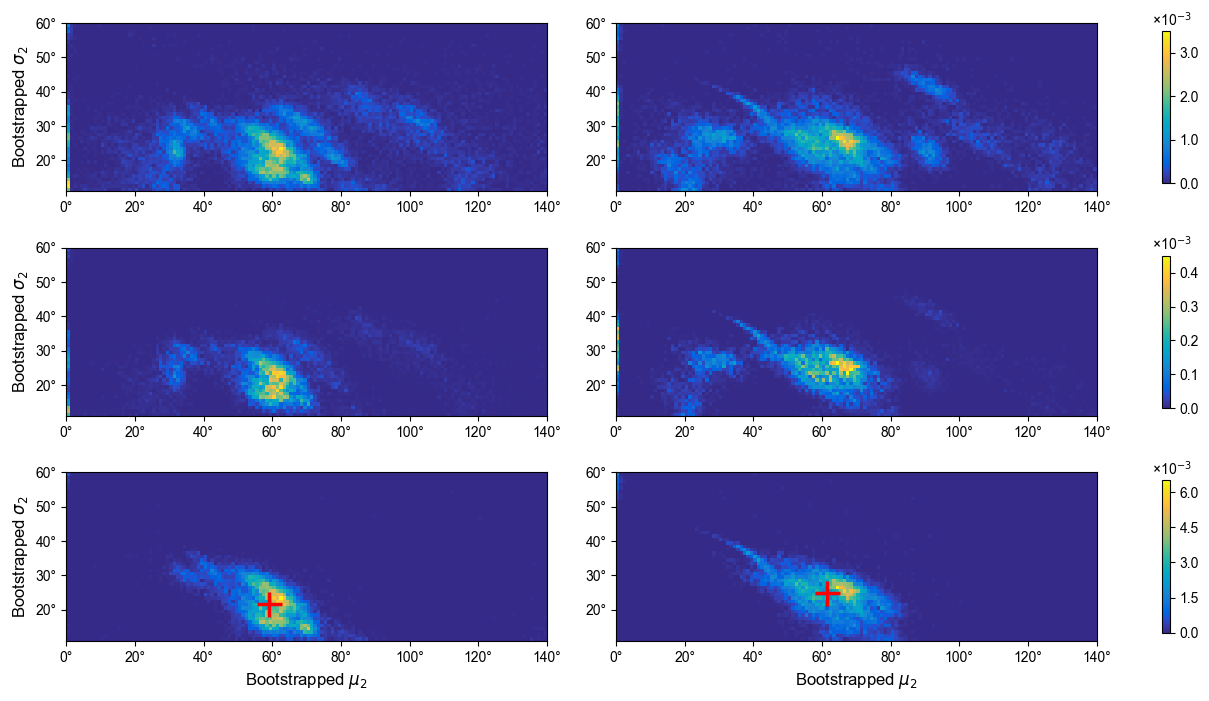

In [211]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from matplotlib.ticker import StrMethodFormatter

# ── Load both datasets ───────────────────────────────────────────────
with open('260605_37PP0Atshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df_ori_raw = pickle.load(f)
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df_alt_raw = pickle.load(f)
df_alt_raw = df_alt_raw[df_alt_raw['index'].isin(heatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)]
x_bins = np.arange(0, 141, 1)
y_bins = np.arange(11, 61, 1)

# ── Helpers ──────────────────────────────────────────────────────────
def filter_df(df_raw):
    df = df_raw[(df_raw['mu']    >= 0)  & (df_raw['mu']    <= 140) &
                (df_raw['sigma'] >= 11) & (df_raw['sigma'] <= 60)].copy()
    df = df[(1 - df['c2']) > 1.0001 * df['c2']]
    return df.reset_index(drop=True)

def compute_combined(df):
    hist, _, _ = np.histogram2d(df['mu'], df['sigma'],
                                bins=(x_bins, y_bins), density=True)
    mu_idx = np.clip(np.digitize(df['mu'],    x_bins) - 1, 0, len(x_bins) - 2)
    sg_idx = np.clip(np.digitize(df['sigma'], y_bins) - 1, 0, len(y_bins) - 2)

    pairs = pd.DataFrame({'mu_bin': mu_idx, 'sg_bin': sg_idx,
                          'mol':    df['index'].values}).drop_duplicates()
    counts = pairs.groupby(['mu_bin', 'sg_bin']).size()
    mol_count = np.zeros_like(hist, dtype=int)
    mol_count[counts.index.get_level_values(0),
              counts.index.get_level_values(1)] = counts.values

    n_total_mols = df['index'].nunique()
    combined     = hist * (mol_count / n_total_mols)
    return hist, combined, (mu_idx, sg_idx), n_total_mols

def run_watershed(combined, sigma_smooth=1.0,
                  min_distance=10, peak_thresh_frac=0.30,
                  bg_thresh_frac=0.30):
    combined_s  = gaussian_filter(combined, sigma=sigma_smooth)
    peak_coords = peak_local_max(combined_s, min_distance=min_distance,
                                 threshold_abs=peak_thresh_frac * combined_s.max())
    markers = np.zeros_like(combined_s, dtype=int)
    for i, (r, c) in enumerate(peak_coords):
        markers[r, c] = i + 1
    seg_mask  = combined_s > bg_thresh_frac * combined_s.max()
    labels_2d = watershed(-combined_s, markers=markers, mask=seg_mask)
    return combined_s, labels_2d, peak_coords

def molecules_in_cluster(df, labels_2d, mu_idx, sg_idx,
                         cluster_id=1, fraction_thresh=0.10):
    df = df.copy()
    df['watershed'] = labels_2d[mu_idx, sg_idx]
    n_in  = df[df['watershed'] == cluster_id]['index'].value_counts()
    n_tot = df['index'].value_counts()
    frac  = (n_in / n_tot).fillna(0)
    keep  = frac[frac > fraction_thresh].index
    return df[df['index'].isin(keep)].reset_index(drop=True), list(keep)

# ── Run pipeline on both datasets ────────────────────────────────────
results = {}
for name, df_raw in [('37PP0At', df_ori_raw), ('37PPnsIHF', df_alt_raw)]:
    df                                   = filter_df(df_raw)
    hist, combined, (mu_i, sg_i), n_mols = compute_combined(df)
    combined_s, labels_2d, peaks         = run_watershed(combined)
    df_subset, qual_mols                 = molecules_in_cluster(
        df, labels_2d, mu_i, sg_i, cluster_id=1, fraction_thresh=0.10)
    results[name] = dict(df=df, hist=hist, combined=combined,
                         combined_s=combined_s, labels_2d=labels_2d,
                         peaks=peaks, df_subset=df_subset,
                         qual_mols=qual_mols, n_mols=n_mols)
    print(f"{name}: {len(df)} pts, {n_mols} mols → "
          f"{len(qual_mols)} mols ≥10% in cluster 1 "
          f"→ {len(df_subset)} pts retained")

# ── 3×2 grid: density / combined / selected molecules ────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 7), constrained_layout=True)
fig.get_layout_engine().set(h_pad=0.02, hspace=0.02,
                            w_pad=0.04, wspace=0.04)
VMAX_ROW = [0.0035, 0.00045, 0.0065]      # max intensity per row

for col, name in enumerate(['37PP0At', '37PPnsIHF']):
    R = results[name]

    # Row 1 — raw density
    mesh_r1 = axes[0, col].pcolormesh(
        x_bins, y_bins, R['hist'].T,
        cmap=parula_map, shading='flat', vmin=0, vmax=VMAX_ROW[0])
    # axes[0, col].set_title(f'{name} — density   (n_mols = {R["n_mols"]})')

    # Row 2 — combined (just the product, no overlays)
    mesh_r2 = axes[1, col].pcolormesh(
        x_bins, y_bins, R['combined'].T,
        cmap=parula_map, shading='flat', vmin=0, vmax=VMAX_ROW[1])
    # axes[1, col].set_title(rf'{name} — $\rho \times f_{{mol}}$')

    # Row 3 — density of selected molecules (≥10% in cluster 1)
    if len(R['df_subset']) > 0:
        hist_sub, _, _ = np.histogram2d(R['df_subset']['mu'],
                                        R['df_subset']['sigma'],
                                        bins=(x_bins, y_bins), density=True)
        mesh_r3 = axes[2, col].pcolormesh(
            x_bins, y_bins, hist_sub.T,
            cmap=parula_map, shading='flat', vmin=0, vmax=VMAX_ROW[2])
        axes[2, col].plot(R['df_subset']['mu'].mean(), R['df_subset']['sigma'].mean(), 'r+', markersize=18, markeredgewidth=2.5)
        
    else:
        axes[2, col].text(0.5, 0.5, 'No qualifying molecules',
                          ha='center', va='center',
                          transform=axes[2, col].transAxes)
        mesh_r3 = None

# ── One colorbar per row, on the right of the second column ─────────
from matplotlib.ticker import FuncFormatter, LinearLocator

def format_cbar(cbar, step=None, scale=1e3, target_n=4):
    """
    Labeled ticks at multiples of `step`, all strictly less than vmax,
    so the colorbar shows a visible gap between the last tick and the
    upper limit.

    If `step` is None, an automatic step from {1, 2, 5} × 10^k is chosen
    that gives roughly `target_n` ticks.
    """
    vmax = cbar.mappable.get_clim()[1]
    eps  = 1e-9

    if step is None:
        # Pick a nice step from {1, 2, 5} × 10^k
        rough = vmax / target_n
        mag   = 10 ** np.floor(np.log10(rough))
        cand  = [m * f for m in (mag / 10, mag, mag * 10) for f in (1, 2, 5)]
        cand  = [s for s in cand if s < vmax]
        step  = min(cand,
                    key=lambda s: abs(int(np.floor(vmax / s - eps)) + 1 - target_n))

    # Largest multiple of step strictly less than vmax
    k_max = int(np.floor(vmax / step - eps))
    ticks  = np.arange(0, k_max + 1) * step
    labels = [f'{t * scale:.1f}' for t in ticks]

    cbar.set_ticks(ticks)
    cbar.set_ticklabels(labels)
    cbar.ax.set_title(r'   ×10$^{-3}$', fontsize=10, pad=4)
    cbar.set_label('')
    cbar.ax.tick_params(labelsize=10)


cbar1 = fig.colorbar(mesh_r1, ax=axes[0, :], location='right', shrink=0.7)
cbar2 = fig.colorbar(mesh_r2, ax=axes[1, :], location='right', shrink=0.7)
cbar3 = fig.colorbar(mesh_r3, ax=axes[2, :], location='right', shrink=0.7)

# for cb in (cbar1, cbar2, cbar3):
format_cbar(cbar1, step=0.001)     # 0.0035 → 4 ticks
format_cbar(cbar2, step=0.0001)    # 0.00045 → 5 ticks
format_cbar(cbar3, step=0.001)     # 0.006 → 6 ticks (denser)
# or
format_cbar(cbar3,step=0.0015)     # 0.006 → 3 ticks (sparser)

# ── Common formatting ───────────────────────────────────────────────
for ax in axes.flat:
    ax.set_xlim(0, 140); ax.set_ylim(11, 60); ax.set_aspect('equal')
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
for row in range(3):
    axes[row, 0].set_ylabel(r'Bootstrapped $\sigma_2$', fontsize=12)
for col in range(2):
    
    axes[2, col].set_xlabel(r'Bootstrapped $\mu_2$', fontsize=12)

plt.savefig('260623_full_pipeline_comparison.svg', bbox_inches='tight')
plt.show()

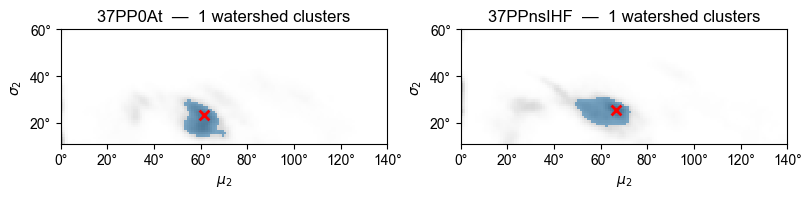

In [194]:

from matplotlib.ticker import StrMethodFormatter

da = (x_bins[1] - x_bins[0]) * (y_bins[1] - y_bins[0])
x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2
MU, SG    = np.meshgrid(x_centers, y_centers, indexing='ij')

fig, axes = plt.subplots(1, 2, figsize=(8, 8), constrained_layout=True)

for ax, name in zip(axes, ['37PP0At', '37PPnsIHF']):
    R = results[name]
    labels_2d = R['labels_2d']
    n_clusters = labels_2d.max()

    # Background: smoothed combined heatmap
    ax.pcolormesh(x_bins, y_bins, R['combined_s'].T,
                  cmap='gray_r', shading='flat', alpha=0.55)

    # Colored watershed regions
    region_disp = np.ma.masked_where(labels_2d.T == 0, labels_2d.T)
    ax.pcolormesh(x_bins, y_bins, region_disp,
                  cmap='tab10', shading='flat', alpha=0.5,
                  vmin=0.5, vmax=10.5)

    # Cluster labels: id + area
    for k in range(1, n_clusters + 1):
        mask  = (labels_2d == k)
        n_pix = mask.sum()
        if n_pix == 0:
            continue
        area = n_pix * da
        w = R['hist'] * mask
        W = w.sum()
        xc = (w * MU).sum() / W if W > 0 else MU[mask].mean()
        yc = (w * SG).sum() / W if W > 0 else SG[mask].mean()
        # ax.text(xc, yc, f'{k}\n{area:.0f}°²',
        #         ha='center', va='center', fontsize=9, color='black',
        #         bbox=dict(facecolor='white', alpha=0.75,
        #                   edgecolor='none', pad=2))

    # Watershed peaks
    if len(R['peaks']):
        peak_mu = (x_bins[:-1] + 0.5)[R['peaks'][:, 0]]
        peak_sg = (y_bins[:-1] + 0.5)[R['peaks'][:, 1]]
        ax.scatter(peak_mu, peak_sg, marker='x', color='red',
                   s=50, linewidths=2, zorder=5)

    ax.set_title(f'{name}  —  {n_clusters} watershed clusters')
    ax.set_xlim(0, 140); ax.set_ylim(11, 60); ax.set_aspect('equal')
    ax.set_xlabel(r'$\mu_2$'); ax.set_ylabel(r'$\sigma_2$')
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))

plt.show()

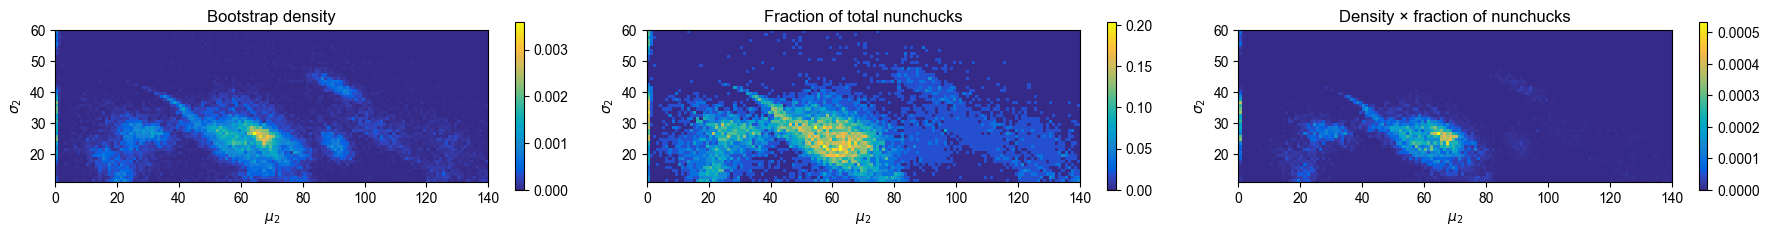

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df = pickle.load(f)

df = df[(df['mu'] >= 0) & (df['mu'] <= 140) &
        (df['sigma'] >= 11) & (df['sigma'] <= 60)]
df = df[((1 - df['c2']) > 1.0001 * df['c2'])]
df.reset_index(inplace=True, drop=True)
df = df[df['index'].isin(heatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)]
n_total_mols = df['index'].nunique()

x_bins = np.arange(0, 141, 1)
y_bins = np.arange(11, 61, 1)

# ── 1) Bootstrap density ────────────────────────────────────────────
hist, _, _ = np.histogram2d(
    df['mu'], df['sigma'],
    bins=(x_bins, y_bins), density=True,
)

# ── 2) Unique-molecule count per bin ────────────────────────────────
mu_idx = np.clip(np.digitize(df['mu'],    x_bins) - 1, 0, len(x_bins) - 2)
sg_idx = np.clip(np.digitize(df['sigma'], y_bins) - 1, 0, len(y_bins) - 2)

pairs = pd.DataFrame({
    'mu_bin': mu_idx, 'sg_bin': sg_idx, 'mol': df['index'].values,
}).drop_duplicates()
counts = pairs.groupby(['mu_bin', 'sg_bin']).size()



mol_count = np.zeros_like(hist, dtype=int)
mol_count[counts.index.get_level_values(0),
          counts.index.get_level_values(1)] = counts.values

# ── 3) Combined: density × #molecules ───────────────────────────────
combined = hist * mol_count / n_total_mols

# ── 4) Plot ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, arr, title, cbar_label in zip(
    axes,
    [hist, mol_count.astype(float)/n_total_mols, combined],
    ['Bootstrap density', 'Fraction of total nunchucks', 'Density × fraction of nunchucks'],
    ['ρ', 'N_mol', 'ρ · N_mol'],
):
    m = ax.pcolormesh(x_bins, y_bins, arr.T, cmap=parula_map, shading='flat')
    plt.colorbar(m, ax=ax, shrink=0.4)
    ax.set_title(title); ax.set_xlabel(r'$\mu_2$'); ax.set_ylabel(r'$\sigma_2$')
    ax.set_xlim(0, 140); ax.set_ylim(11, 60); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('260623_prewatershed_alt.png',dpi=300)

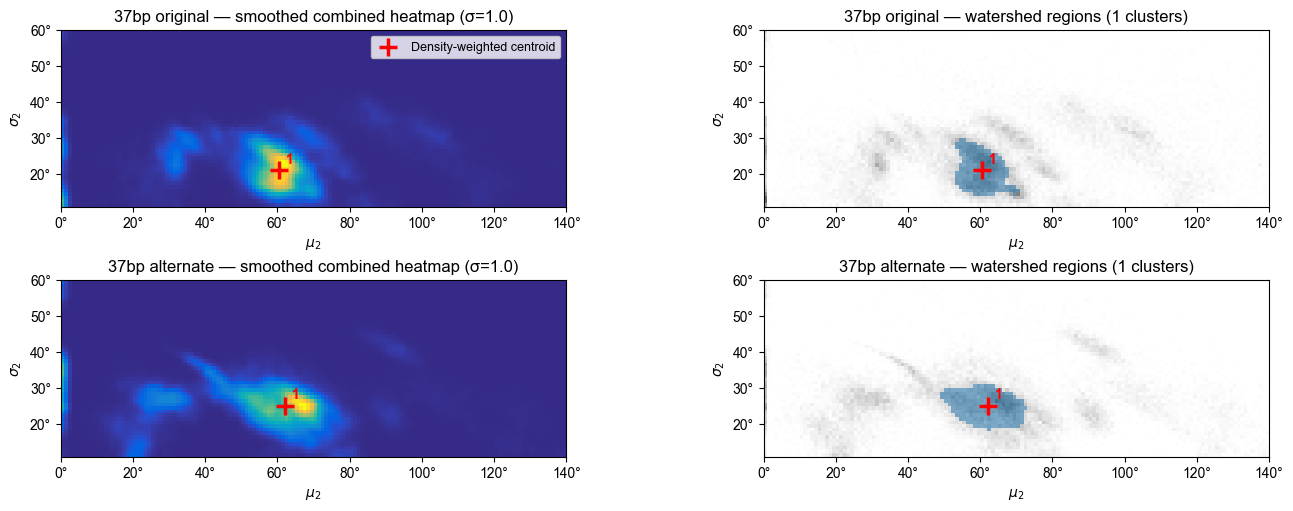


37PP0At:
  Cluster 1: density-weighted centroid = (60.57°, 21.05°)

37PPnsIHF:
  Cluster 1: density-weighted centroid = (62.20°, 25.14°)


In [209]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

SIGMA_SMOOTH = 1.0   # for the title only — data already smoothed in `results`

x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2
MU, SG    = np.meshgrid(x_centers, y_centers, indexing='ij')

fig, axes = plt.subplots(2, 2, figsize=(14, 5), constrained_layout=True)
title_label = ['37bp original', '37bp alternate']

for row, name in enumerate(['37PP0At', '37PPnsIHF']):
    R          = results[name]
    combined_s = R['combined_s']
    labels_2d  = R['labels_2d']
    hist       = R['hist']
    peaks      = R['peaks']
    n_clusters = labels_2d.max()

    # ── Density-weighted centroid per cluster (uses hist) ───────────
    cluster_centroids = {}
    for k in range(1, n_clusters + 1):
        mask = (labels_2d == k)
        w = hist * mask
        W = w.sum()
        if W > 0:
            cluster_centroids[k] = ((w * MU).sum() / W, (w * SG).sum() / W)
        else:
            cluster_centroids[k] = (np.nan, np.nan)

    # ── Left panel: smoothed combined heatmap ────────────────────────
    ax = axes[row, 0]
    ax.pcolormesh(x_bins, y_bins, combined_s.T,
                  cmap=parula_map, shading='flat')
    ax.set_title(f'{title_label[row]} — smoothed combined heatmap (σ={SIGMA_SMOOTH})')

    # ── Right panel: watershed regions over raw density ──────────────
    ax = axes[row, 1]
    ax.pcolormesh(x_bins, y_bins, hist.T,
                  cmap='gray_r', shading='flat', alpha=0.6)
    ax.pcolormesh(x_bins, y_bins,
                  np.ma.masked_where(labels_2d.T == 0, labels_2d.T),
                  cmap='tab10', shading='flat', alpha=0.5,
                  vmin=0.5, vmax=10.5)
    ax.set_title(f'{title_label[row]} — watershed regions ({n_clusters} clusters)')

    # ── Overlays: centroids + labels on both panels ──────────────────
    for ax_i in (axes[row, 0], axes[row, 1]):
        for k, (cx, cy) in cluster_centroids.items():
            if np.isnan(cx):
                continue
            ax_i.scatter(cx, cy, marker='+', color='red',
                         s=150, linewidths=2.5, zorder=5)
            ax_i.annotate(f'{k}', (cx, cy), xytext=(5, 5),
                          textcoords='offset points', color='red',
                          fontsize=10, fontweight='bold')

        ax_i.set_xlim(0, 140); ax_i.set_ylim(11, 60); ax_i.set_aspect('equal')
        ax_i.set_xlabel(r'$\mu_2$'); ax_i.set_ylabel(r'$\sigma_2$')
        ax_i.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
        ax_i.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))

# Single legend entry for the centroid markers
axes[0, 0].scatter([], [], marker='+', color='red',
                   s=150, linewidths=2.5, label='Density-weighted centroid')
axes[0, 0].legend(loc='upper right', fontsize=9)

plt.savefig('260623_watershed_both.png', dpi=300, bbox_inches='tight')
plt.show()

# Print centroid summary
for name in ['37PP0At', '37PPnsIHF']:
    R = results[name]
    print(f'\n{name}:')
    for k in range(1, R['labels_2d'].max() + 1):
        mask = (R['labels_2d'] == k)
        w = R['hist'] * mask
        W = w.sum()
        if W > 0:
            cx = (w * MU).sum() / W
            cy = (w * SG).sum() / W
            print(f'  Cluster {k}: density-weighted centroid = ({cx:.2f}°, {cy:.2f}°)')



In [216]:
print(results['37PPnsIHF']['df_subset']['mu'].mean())
print(results['37PPnsIHF']['df_subset']['mu'].std())
print(results['37PPnsIHF']['df_subset']['sigma'].mean())
print(results['37PPnsIHF']['df_subset']['sigma'].std())

61.39591005437304
11.268251700881846
24.785401689133035
6.118582624825181


In [196]:
print(results['37PP0At']['df_subset']['mu'].mean())
print(results['37PP0At']['df_subset']['mu'].std())
print(results['37PP0At']['df_subset']['sigma'].mean())
print(results['37PP0At']['df_subset']['sigma'].std())

59.03528545390691
9.257895594313881
21.825149503008724
5.6773454414238715


In [215]:
df_alt_raw['index'].nunique()

58

In [29]:
unique_37PP0At = results['37PP0At']['df_subset']['index'].unique()
ruiyao_37PP0At = np.where(np.isin(amber_data_3['data']['name'][0][0][0], unique_37PP0At))[0]
ruiyao_37PP0At_data = heatmap_movies_37ori[np.concatenate(amber_data_3['data']['name'][0][0][0][ruiyao_37PP0At])]
ruiyao_37PP0At_conc = np.concatenate(ruiyao_37PP0At_data.reset_index(drop=1))

ruiyao_37PP0At_data_short = heatmap_37PP0At[np.concatenate(amber_data_3['data']['name'][0][0][0][ruiyao_37PP0At])]
ruiyao_37PP0At_conc_short = np.concatenate(ruiyao_37PP0At_data_short.reset_index(drop=1))


In [214]:
unique_37PPnsIHF = results['37PPnsIHF']['df_subset']['index'].unique()
ruiyao_37PPnsIHF = np.where(np.isin(amber_data_3['data']['name'][0][0][0], unique_37PPnsIHF))[0]
# ruiyao_37PPnsIHF = np.where(np.isin(amber_data_3['data']['name'][0][0][0], np.concatenate([unique_37PPnsIHF, ['230330_5pm_9_37PPnsIHF', '230331_4pm_4_37PPnsIHF']])))[0]
ruiyao_37PPnsIHF_data = heatmap_movies_37alt[np.concatenate(amber_data_3['data']['name'][0][0][0][ruiyao_37PPnsIHF])]
ruiyao_37PPnsIHF_conc = np.concatenate(ruiyao_37PPnsIHF_data.reset_index(drop=1))

ruiyao_37PPnsIHF_data_short = heatmap_37PPnsIHF[np.concatenate(amber_data_3['data']['name'][0][0][0][ruiyao_37PPnsIHF])]
ruiyao_37PPnsIHF_conc_short = np.concatenate(ruiyao_37PPnsIHF_data_short.reset_index(drop=1))

print(len(ruiyao_37PPnsIHF))
print(ruiyao_37PPnsIHF)

20
[1938 1941 1942 1945 1947 1952 1954 1955 1963 1965 1967 1968 1973 1976
 1978 1982 1983 1987 1990 1994]


Bootstrap: 500/500 accepted (runtime errors: 0, R² rejects: 0, c2 rejects: 0)
  Original R² = 0.9927, threshold = 0.9427


(array([ 0.17981978, 59.21842498, 25.19077506]),
 np.float64(1.2464360274680029),
 np.float64(0.7096553897030032),
 np.float64(0.016512701162702148))

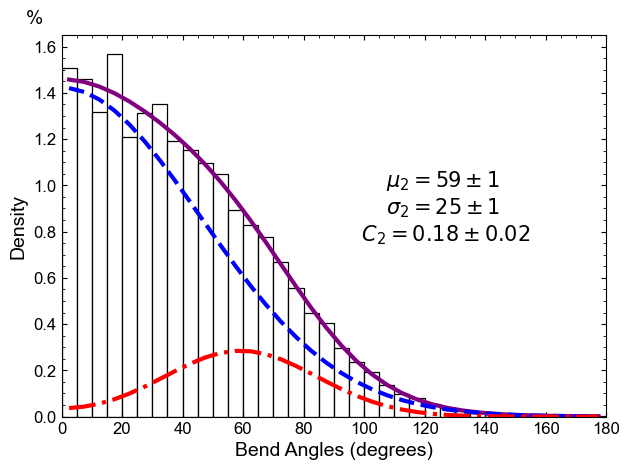

In [1206]:
ruiyao_both_conc_short = np.concatenate([ruiyao_37PP0At_conc_short,ruiyao_37PPnsIHF_conc_short])
plot_bootstrap_2tf_fit(ruiyao_both_conc_short,m1=0,sigma1=46)
# plt.savefig('260608_aggregate_both.png')

In [1066]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


def plot_cluster_density(
    df,
    cluster_id=None,
    df_subset=None,
    *,
    cluster_col='watershed',
    mol_col='index',
    x='mu', y='sigma',
    x_range=(0, 140), y_range=(11, 60),
    binwidth=(1, 1),
    vmax=0.0035,
    cmap=None,
    ax=None,
    figsize=(9, 4),
    xlabel=r'Bootstrapped $\mu_2$',
    ylabel=r'Bootstrapped $\sigma_2$',
    title=None,
    cbar_shrink=0.4,
    cbar_scale=1e3,
    cbar_scale_label=r'   ×10$^{-3}$',
):
    """
    Heatmap of bootstrap density for the molecules belonging to a
    watershed (or otherwise pre-labeled) cluster.

    Parameters
    ----------
    df : DataFrame
        Full bootstrap dataframe with columns mu, sigma, index, and a
        cluster-label column (default 'watershed').
    cluster_id : int or None
        Which cluster's molecules to plot. Selects all bootstrap rows for
        every molecule that has at least one row in this cluster.
    df_subset : DataFrame or None
        Optional: pass a pre-filtered subset directly. Overrides cluster_id.
    ax : matplotlib Axes or None
        If None, creates a new figure.

    Returns
    -------
    dict with keys:
        'ax'        : Axes object
        'fig'       : Figure object
        'cbar'      : Colorbar object
        'df_subset' : The filtered dataframe actually plotted
    """
    # ── Resolve the subset ─────────────────────────────────────────────
    if df_subset is None:
        if cluster_id is None:
            raise ValueError("Provide either `cluster_id` or `df_subset`")
        mols_in_cluster = df.loc[df[cluster_col] == cluster_id, mol_col].unique()
        df_subset = df[df[mol_col].isin(mols_in_cluster)].copy()

    # ── Setup axes ─────────────────────────────────────────────────────
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # ── Heatmap ────────────────────────────────────────────────────────
    sns.histplot(
        df_subset, x=x, y=y,
        vmax=vmax,
        binwidth=binwidth,
        binrange=(x_range, y_range),
        stat='density',
        cmap=cmap,
        common_norm=True,
        ax=ax,
    )

    # ── Colorbar ───────────────────────────────────────────────────────
    cbar = fig.colorbar(ax.collections[0], ax=ax, shrink=cbar_shrink)
    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda v, _: f'{v * cbar_scale:.1f}')
    )
    cbar.ax.set_title(cbar_scale_label, fontsize=10, pad=4)
    cbar.set_label('')
    cbar.ax.tick_params(labelsize=10)

    # ── Axis labels & formatting ───────────────────────────────────────
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_aspect('equal')
    ax.margins(0)
    if title is not None:
        ax.set_title(title, fontsize=13)

    n_mols = df_subset[mol_col].nunique()
    n_rows = len(df_subset)
    print(f"Plotted {n_rows} bootstrap rows from {n_mols} unique molecules")

    return {
        'ax':        ax,
        'fig':       fig,
        'cbar':      cbar,
        'df_subset': df_subset,
    }


In [191]:
def compute_rg_array(df, x_bins, y_bins):
    """Per-molecule R_g and iteration count, aligned with returned mols."""
    mols   = df['index'].unique()
    rg     = np.full(len(mols), np.nan)
    n_iter = np.zeros(len(mols), dtype=int)
    for i, mol in enumerate(mols):
        sub = df[df['index'] == mol]
        n_iter[i] = len(sub)
        hist, _, _ = np.histogram2d(
            sub['mu'], sub['sigma'],
            bins=(x_bins, y_bins), density=True,
        )
        rg[i] = compute_tightness_metrics(hist, x_bins, y_bins)['R_g']
    return rg, n_iter, mols

rg_37PP0At,   n_37PP0At,   mols_37PP0At   = compute_rg_array(df_ori, x_bins, y_bins)
rg_37PPnsIHF, n_37PPnsIHF, mols_37PPnsIHF = compute_rg_array(df_alt, x_bins, y_bins)

print(f"rg_37PP0At:    {len(rg_37PP0At):3d} mols, "
      f"R_g median = {np.nanmedian(rg_37PP0At):.2f}°, "
      f"n_iter range = [{n_37PP0At.min()}, {n_37PP0At.max()}], "
      f"median = {int(np.median(n_37PP0At))}")
print(f"rg_37PPnsIHF:  {len(rg_37PPnsIHF):3d} mols, "
      f"R_g median = {np.nanmedian(rg_37PPnsIHF):.2f}°, "
      f"n_iter range = [{n_37PPnsIHF.min()}, {n_37PPnsIHF.max()}], "
      f"median = {int(np.median(n_37PPnsIHF))}")


rg_37PP0At:     81 mols, R_g median = 7.71°, n_iter range = [1, 955], median = 233
rg_37PPnsIHF:   54 mols, R_g median = 8.11°, n_iter range = [1, 980], median = 343


In [192]:
df_alt['index'].unique()

<StringArray>
[   'movie220326_12pm_01_37PP_nsIHF',    'movie220326_12pm_02_37PP_nsIHF',
    'movie220326_12pm_04_37PP_nsIHF',    'movie220326_12pm_05_37PP_nsIHF',
    'movie220326_12pm_06_37PP_nsIHF',    'movie220326_12pm_07_37PP_nsIHF',
    'movie220326_12pm_08_37PP_nsIHF',    'movie220326_12pm_09_37PP_nsIHF',
    'movie220326_12pm_10_37PP_nsIHF',    'movie220326_12pm_11_37PP_nsIHF',
    'movie220326_12pm_12_37PP_nsIHF',    'movie220326_12pm_13_37PP_nsIHF',
    'movie220326_12pm_14_37PP_nsIHF',    'movie220326_12pm_15_37PP_nsIHF',
 'movie220326_12pm_16nca_37PP_nsIHF', 'movie220326_12pm_16ncb_37PP_nsIHF',
    'movie220326_12pm_17_37PP_nsIHF',    'movie220326_12pm_18_37PP_nsIHF',
    'movie220326_12pm_19_37PP_nsIHF',    'movie220326_12pm_20_37PP_nsIHF',
    'movie220326_12pm_21_37PP_nsIHF',    'movie220326_12pm_22_37PP_nsIHF',
    'movie220326_12pm_23_37PP_nsIHF',    'movie220326_12pm_24_37PP_nsIHF',
    'movie220326_12pm_25_37PP_nsIHF',    'movie220326_12pm_26_37PP_nsIHF',
           

In [193]:
# sum((n_37PP0At>50) & (rg_37PP0At<10) )
sum((n_37PPnsIHF>50) & (rg_37PPnsIHF<10) )

np.int64(25)

In [62]:
import numpy as np

def compute_mi_compactness_weighted(hist2d, x_edges, y_edges):
    """
    Intensity-weighted MI compactness (Li et al. 2013, Section 7).
    
    Each pixel's contribution to the centroid and I_g is weighted by its
    density value ρ (the histogram value when density=True).
    
    Normalized so a uniform disk gives C = 1 regardless of density level:
        C = M · A_support / (2π · I_g)
    
    where:
        M         = ∫ρ dA           (total mass; = 1 for density=True hists)
        A_support = ∫dA over ρ>0    (footprint of occupied bins)
        I_g       = ∫ρ · z_g² dA    (density-weighted MI about weighted centroid)
    """
    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]
    da = dx * dy
    
    # Pixel centers
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2.0
    XX, YY = np.meshgrid(x_centers, y_centers, indexing='ij')
    
    mask = hist2d > 0
    if mask.sum() == 0:
        return np.nan, dict(cx=np.nan, cy=np.nan, I_g=np.nan, M=0, A_support=0)
    
    rho   = hist2d[mask]    # density values = weights
    x_occ = XX[mask]
    y_occ = YY[mask]
    
    # Total mass (≈1 because density=True)
    M = np.sum(rho * da)
    
    # Density-weighted centroid
    cx = np.sum(rho * x_occ * da) / M
    cy = np.sum(rho * y_occ * da) / M
    
    # Density-weighted MI about the weighted centroid
    z_sq = (x_occ - cx)**2 + (y_occ - cy)**2
    I_g_inter = np.sum(rho * z_sq * da)
    # Pixel self-MI (parallel axis term): ρ · da · (dx²+dy²)/12 per pixel
    I_g_self  = M * (dx**2 + dy**2) / 12.0
    I_g = I_g_inter + I_g_self
    
    # Support footprint (number of occupied bins × bin area)
    A_support = mask.sum() * da
    
    # Normalized compactness (gives 1 for a uniform disk of any density)
    C_MI = M * A_support / (2.0 * np.pi * I_g)
    
    return C_MI, dict(cx=cx, cy=cy, I_g=I_g, M=M, A_support=A_support)

In [189]:
x_bins = np.arange(0, 141, 1)
y_bins = np.arange(11, 61, 1)

def filter_df(df):
    df = df[(1 - df['c2']) > 1.0001 * df['c2']]
    df = df[(df['mu'] >= 0) & (df['mu'] <= 140) &
            (df['sigma'] >= 11) & (df['sigma'] <= 60)]
    return df.reset_index(drop=True)
def compute_mi_compactness_HDR(hist2d, x_edges, y_edges, mass_fraction=0.95):
    """
    Intensity-weighted compactness restricted to the highest-density region (HDR)
    containing `mass_fraction` of the total bootstrap mass.
    
    Robust to sparse outliers: bins with low density that collectively account
    for less than (1 - mass_fraction) of the mass are discarded before computing C.
    """
    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]
    da = dx * dy
    
    # Sort all bin densities descending, find threshold that captures mass_fraction
    rho_sorted = np.sort(hist2d.flatten())[::-1]
    cum_mass   = np.cumsum(rho_sorted) * da
    total_mass = cum_mass[-1]
    if total_mass == 0:
        return np.nan, dict()
    
    idx = np.searchsorted(cum_mass, mass_fraction * total_mass)
    threshold = rho_sorted[min(idx, len(rho_sorted) - 1)]
    
    # Keep bins at/above threshold, renormalize so mass = 1
    hist_HDR = np.where(hist2d >= threshold, hist2d, 0.0)
    M_HDR = np.sum(hist_HDR * da)
    if M_HDR > 0:
        hist_HDR = hist_HDR / M_HDR
    
    C_MI, diag = compute_mi_compactness_weighted(hist_HDR, x_edges, y_edges)
    diag['threshold']           = threshold
    diag['n_pixels_kept']       = int(np.sum(hist_HDR > 0))
    diag['n_pixels_discarded']  = int(np.sum((hist2d > 0) & (hist_HDR == 0)))
    diag['mass_fraction']       = mass_fraction
    return C_MI, diag
def compute_rg_array(df, x_bins, y_bins):
    """Per-molecule R_g, returned in the order of df['index'].unique()."""
    mols = df['index'].unique()
    rg = np.full(len(mols), np.nan)
    for i, mol in enumerate(mols):
        sub = df[df['index'] == mol]
        hist, _, _ = np.histogram2d(
            sub['mu'], sub['sigma'],
            bins=(x_bins, y_bins), density=True,
        )
        rg[i] = compute_tightness_metrics(hist, x_bins, y_bins)['R_g']
    return rg, mols

# ── 37PP0At ──────────────────────────────────────────────────────────
with open('260605_37PP0Atshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df_ori = pickle.load(f)
df_ori = filter_df(df_ori)
rg_37PP0At, mols_37PP0At = compute_rg_array(df_ori, x_bins, y_bins)

# ── 37PPnsIHF ────────────────────────────────────────────────────────
with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df_alt_raw = pickle.load(f)
df_alt_raw = df_alt_raw[df_alt_raw['index'].isin(heatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)]
df_alt = filter_df(df_alt_raw)
rg_37PPnsIHF, mols_37PPnsIHF = compute_rg_array(df_alt, x_bins, y_bins)

# Summary
print(f"rg_37PP0At:    {len(rg_37PP0At):3d} mols, "
      f"R_g median = {np.nanmedian(rg_37PP0At):.2f}°, "
      f"mean = {np.nanmean(rg_37PP0At):.2f}°, "
      f"std = {np.nanstd(rg_37PP0At):.2f}°")
print(f"rg_37PPnsIHF:  {len(rg_37PPnsIHF):3d} mols, "
      f"R_g median = {np.nanmedian(rg_37PPnsIHF):.2f}°, "
      f"mean = {np.nanmean(rg_37PPnsIHF):.2f}°, "
      f"std = {np.nanstd(rg_37PPnsIHF):.2f}°")

rg_37PP0At:     81 mols, R_g median = 7.71°, mean = 11.84°, std = 11.82°
rg_37PPnsIHF:   54 mols, R_g median = 8.11°, mean = 11.19°, std = 9.34°


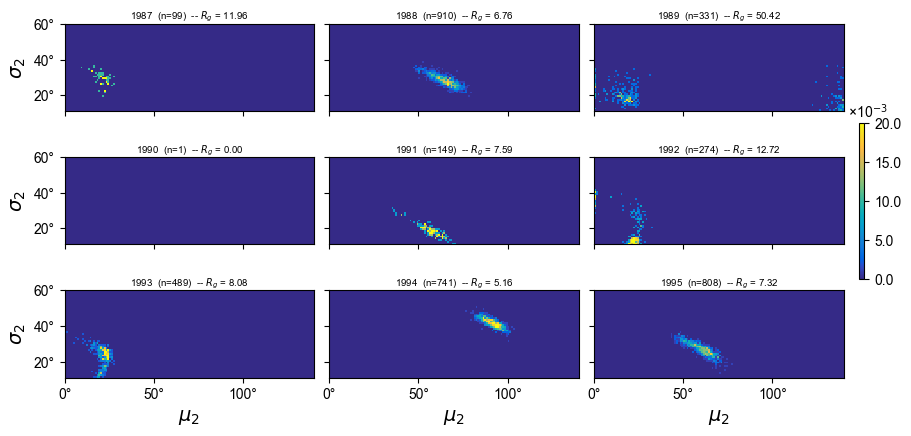

In [187]:
from matplotlib.ticker import StrMethodFormatter, FuncFormatter, MultipleLocator
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

with open('260605_37PPnsIHFshort_bootstrap_wCons_sumto1_seed0_randomInitialCondition_noOptimizer.pkl', 'rb') as f:
    df = pickle.load(f)

df = df[(1 - df['c2']) > 1.0001 * df['c2']]
df['in_bounds'] = (
    (df['mu']    >= 0)  & (df['mu']    <= 140) &
    (df['sigma'] >= 11) & (df['sigma'] <= 60)
)
df = df[df['in_bounds']]
df = df[df['index'].isin(heatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)]

# df = df[np.isin(df['index'],names_data_3[ruiyao_37PPnsIHF].values)]
x_bins = np.arange(0, 141, 1)
y_bins = np.arange(11, 61, 1)

# ── Grid size: change these two numbers to whatever you want ─────────────────
nrows = 3
ncols = 3
n_panels = nrows * ncols
## modify below
mols = (df['index'].unique().tolist())[45:]  ##########################################


global_vmax = 0.02

# ── Layout ────────────────────────────────────────────────────────────────────
# Scale figure size with the grid so panels stay roughly square
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3 * ncols, 1.1 * nrows + 1),
    constrained_layout=True,
    squeeze=False,                       # always 2D, even if nrows or ncols == 1
)

for idx, mol in enumerate(mols):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    sub = df[df['index'] == mol]

    hist, _, _ = np.histogram2d(
        sub['mu'], sub['sigma'],
        bins=(x_bins, y_bins),
        density=True,
    )
    # C_MI, diag = compute_mi_compactness_weighted(hist, x_bins, y_bins)
    C_MI, diag = compute_mi_compactness_HDR(hist, x_bins, y_bins)
    rg = compute_tightness_metrics(hist, x_bins, y_bins)
    mesh = ax.pcolormesh(
        x_bins, y_bins, hist.T,
        cmap=parula_map,
        vmin=0, vmax=global_vmax,
        shading='flat',
    )
    title = names_data_3[names_data_3 ==mol].index[0]+1
    # gmm_ellipse(gmm_37PP0At.means_[0], gmm_37PP0At.covariances_[0],ax,linewidth=2, edgecolor='red', facecolor='none')
    ax.set_title(f'{title}  (n={len(sub)})  -- $R_g$ = {rg['R_g']:.2f}', fontsize=7, pad=2)
    
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}°'))
    ax.set_xlim(0, 140); ax.set_ylim(11, 60)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=10)

    # Only label edges of the actual grid
    is_bottom = (row == nrows - 1)
    is_left   = (col == 0)
    ax.set_xlabel(r'$\mu_2$',   fontsize=14) if is_bottom else ax.set_xlabel('')
    ax.set_ylabel(r'$\sigma_2$', fontsize=14) if is_left   else ax.set_ylabel('')
    if not is_bottom: ax.set_xticklabels([])
    if not is_left:   ax.set_yticklabels([])

# Hide unused panels
for idx in range(len(mols), n_panels):
    row, col = divmod(idx, ncols)
    axes[row, col].set_visible(False)

# ── Single shared colorbar ────────────────────────────────────────────────────
sm = ScalarMappable(cmap=parula_map, norm=Normalize(0, global_vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.4, aspect=30, pad=0.02)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 1e3:.1f}'))
cbar.ax.set_title(r'   ×10$^{-3}$', fontsize=10, pad=4)
cbar.set_label('')
cbar.ax.tick_params(labelsize=10)
cbar.ax.yaxis.set_major_locator(MultipleLocator(0.005))

plt.savefig(f'260623_37PPnsIHF_45-58.png', bbox_inches='tight')
plt.show()

In [61]:
def compute_tightness_metrics(hist2d, x_edges, y_edges):
    """
    Shape-agnostic tightness metrics for a density-weighted distribution.
    Returns: R_g (total spread), sigma_major, sigma_minor (principal axes),
             aspect_ratio, and A_HDR95 (95% highest-density-region area).
    """
    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]
    da = dx * dy
    xc = (x_edges[:-1] + x_edges[1:]) / 2
    yc = (y_edges[:-1] + y_edges[1:]) / 2
    XX, YY = np.meshgrid(xc, yc, indexing='ij')

    mask = hist2d > 0
    if mask.sum() == 0:
        return {k: np.nan for k in
                ['R_g', 'sigma_major', 'sigma_minor', 'aspect_ratio', 'A_HDR95']}

    rho = hist2d[mask]
    x = XX[mask]; y = YY[mask]
    M  = np.sum(rho * da)
    cx = np.sum(rho * x * da) / M
    cy = np.sum(rho * y * da) / M

    # Density-weighted 2x2 covariance
    Cxx = np.sum(rho * (x - cx)**2 * da) / M
    Cyy = np.sum(rho * (y - cy)**2 * da) / M
    Cxy = np.sum(rho * (x - cx)*(y - cy) * da) / M
    Cov = np.array([[Cxx, Cxy], [Cxy, Cyy]])

    # Principal axes: eigenvalues are variances along the natural axes
    eigvals = np.sort(np.linalg.eigvalsh(Cov))[::-1]   # descending
    sigma_major = np.sqrt(max(eigvals[0], 0.0))
    sigma_minor = np.sqrt(max(eigvals[1], 0.0))
    R_g = np.sqrt(Cxx + Cyy)                            # trace invariant

    # Aspect ratio (≥ 1 by construction)
    aspect = sigma_major / sigma_minor if sigma_minor > 0 else np.inf

    # 95% HDR area: smallest set of bins containing 95% of the mass
    rho_sorted = np.sort(hist2d.flatten())[::-1]
    cum = np.cumsum(rho_sorted) * da
    idx = np.searchsorted(cum, 0.95 * cum[-1])
    A_HDR95 = (idx + 1) * da

    return {
        'R_g':          R_g,
        'sigma_major':  sigma_major,
        'sigma_minor':  sigma_minor,
        'aspect_ratio': aspect,
        'A_HDR95':      A_HDR95,
        'centroid_mu':    cx,
        'centroid_sigma': cy,
    }


In [157]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def visualize_tightness(df, x_bins=None, y_bins=None, ax=None, title=None,
                        cmap='viridis'):
    """
    Visualize density-weighted tightness metrics on a (mu, sigma) heatmap.
    Overlays centroid, R_g circle, 1-sigma principal-axes ellipse, and
    HDR-95% boundary.
    """
    if x_bins is None: x_bins = np.arange(0, 141, 1)
    if y_bins is None: y_bins = np.arange(11, 61, 1)

    # ── Build density and compute metrics ──────────────────────────────
    hist, x_edges, y_edges = np.histogram2d(
        df['mu'], df['sigma'], bins=(x_bins, y_bins), density=True,
    )
    metrics = compute_tightness_metrics(hist, x_edges, y_edges)
    cx, cy  = metrics['centroid_mu'], metrics['centroid_sigma']

    # ── Recompute eigenvectors for ellipse orientation ─────────────────
    dx, dy = x_edges[1] - x_edges[0], y_edges[1] - y_edges[0]
    da     = dx * dy
    xc     = (x_edges[:-1] + x_edges[1:]) / 2
    yc     = (y_edges[:-1] + y_edges[1:]) / 2
    XX, YY = np.meshgrid(xc, yc, indexing='ij')
    mask = hist > 0
    rho  = hist[mask]
    M    = np.sum(rho * da)
    Cxx  = np.sum(rho * (XX[mask] - cx)**2 * da) / M
    Cyy  = np.sum(rho * (YY[mask] - cy)**2 * da) / M
    Cxy  = np.sum(rho * (XX[mask] - cx) * (YY[mask] - cy) * da) / M
    Cov  = np.array([[Cxx, Cxy], [Cxy, Cyy]])
    eigvals, eigvecs = np.linalg.eigh(Cov)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
    angle   = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # ── HDR-95% density threshold (for the contour line) ───────────────
    rho_sorted = np.sort(hist.flatten())[::-1]
    cum        = np.cumsum(rho_sorted) * da
    hdr_thresh = rho_sorted[min(np.searchsorted(cum, 0.95 * cum[-1]),
                                len(rho_sorted) - 1)]

    # ── Plot ───────────────────────────────────────────────────────────
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    mesh = ax.pcolormesh(x_edges, y_edges, hist.T, cmap=cmap, shading='flat')
    plt.colorbar(mesh, ax=ax, label='Density', shrink=0.85)

    # HDR-95% boundary
    ax.contour(xc, yc, hist.T, levels=[hdr_thresh],
               colors='white', linewidths=1.5, linestyles=':')

    # 1-σ ellipse (principal axes)
    ax.add_patch(Ellipse(
        xy=(cx, cy),
        width=2 * metrics['sigma_major'],
        height=2 * metrics['sigma_minor'],
        angle=angle,
        facecolor='none', edgecolor='orange', linewidth=2,
        label=fr'1-σ ellipse  ({metrics["sigma_major"]:.1f}°×{metrics["sigma_minor"]:.1f}°)',
    ))

    # R_g circle
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(cx + metrics['R_g'] * np.cos(theta),
            cy + metrics['R_g'] * np.sin(theta),
            'red', lw=2, ls='--',
            label=fr'$R_g$ = {metrics["R_g"]:.2f}°')

    # Centroid
    ax.plot(cx, cy, 'r+', markersize=18, markeredgewidth=2.5,
            label=fr'centroid ({cx:.1f}°, {cy:.1f}°)')

    # Text panel
    text = (fr'$R_g$ = {metrics["R_g"]:.2f}°' + '\n'
            fr'$\sigma_{{maj}}$ = {metrics["sigma_major"]:.2f}°' + '\n'
            fr'$\sigma_{{min}}$ = {metrics["sigma_minor"]:.2f}°' + '\n'
            fr'aspect = {metrics["aspect_ratio"]:.2f}' + '\n'
            fr'$A_{{HDR95}}$ = {metrics["A_HDR95"]:.0f} deg²' + '\n'
            fr'n = {len(df)}')
    ax.text(0.02, 0.98, text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', pad=4))

    ax.set_xlabel(r'$\mu_2$ (°)', fontsize=12)
    ax.set_ylabel(r'$\sigma_2$ (°)', fontsize=12)
    ax.set_ylim(11,60)
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.85)
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    return ax, metrics

(<Axes: xlabel='$\\mu_2$ (°)', ylabel='$\\sigma_2$ (°)'>,
 {'R_g': np.float64(12.521445108140613),
  'sigma_major': np.float64(11.677897480508339),
  'sigma_minor': np.float64(4.518107793193457),
  'aspect_ratio': np.float64(2.584687664623922),
  'A_HDR95': np.int64(681),
  'centroid_mu': np.float64(61.151140164183644),
  'centroid_sigma': np.float64(24.20355731225297)})

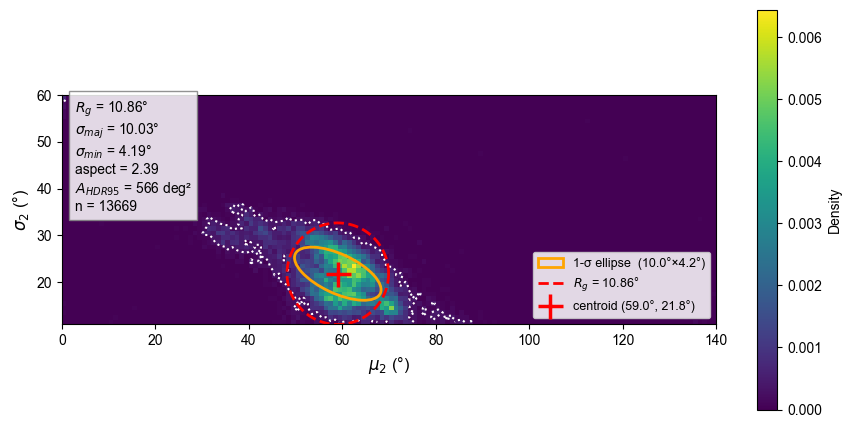

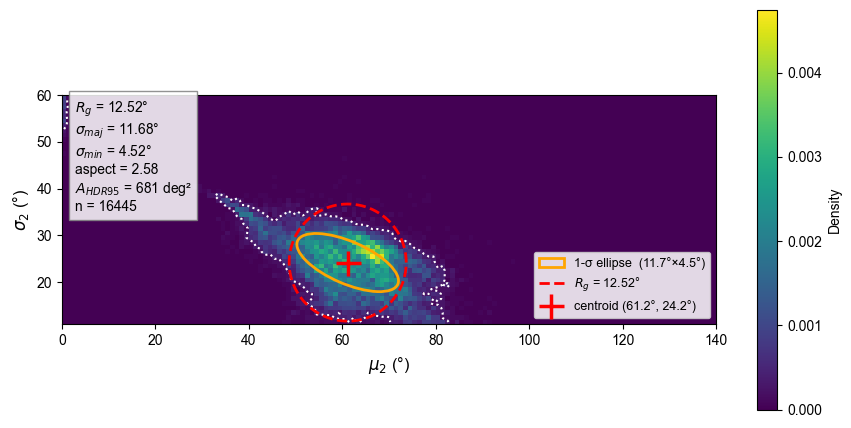

In [1517]:
visualize_tightness(dfheatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)
visualize_tightness(results['37PPnsIHF']['df_subset'])

(<Axes: xlabel='$\\mu_2$ (°)', ylabel='$\\sigma_2$ (°)'>,
 {'R_g': np.float64(28.91054014127223),
  'sigma_major': np.float64(27.958406295227),
  'sigma_minor': np.float64(7.358454232454271),
  'aspect_ratio': np.float64(3.7994944878391954),
  'A_HDR95': np.int64(2155),
  'centroid_mu': np.float64(58.97070905101994),
  'centroid_sigma': np.float64(25.73157354245437)})

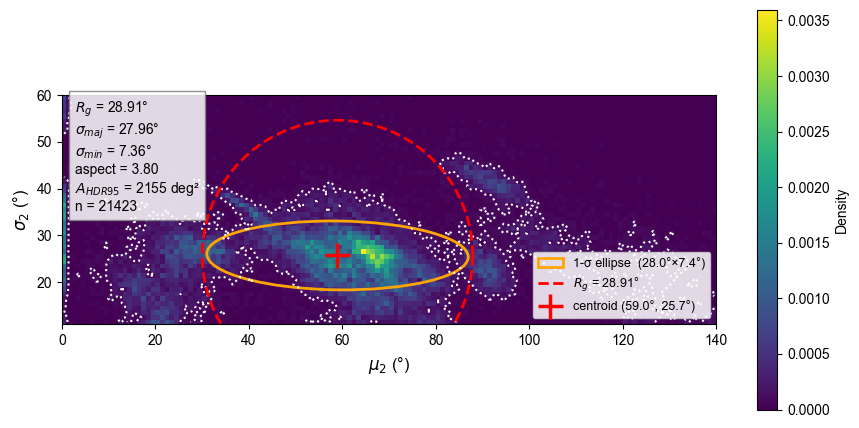

In [158]:
visualize_tightness(df_filt[df_filt['index'].isin(heatmap_37PPnsIHF[~heatmap_37PPnsIHF.index.str.contains('MBN')].index)])